# 04c Loaded 04a Centrality Model Retraining for Dataset 1

Simple experiment using the best classical-feature model saved from notebook 04.

- Dataset 1: keep the same temporal split structure as notebook 04 and train a fresh model using the saved 04a model specs.
- Dataset 2: run two experiments: train a fresh model using the saved 04a specs on a random split, and direct prediction using the saved 04a model without retraining.
- The p-value plots include the baseline as `p0`.

In [1]:
from pathlib import Path
import copy
import os
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.base import clone
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import train_test_split

def find_project_root(start=None):
    start = Path(start or Path.cwd()).resolve()
    for path in [start, *start.parents]:
        if (path / 'src').exists() and (path / 'requirements.txt').exists():
            return path
    raise FileNotFoundError('Project root not found.')


PROJECT_ROOT = find_project_root()
sys.path.insert(0, str(PROJECT_ROOT))
from src.models.ml_train_and_store import (
    CLASSICAL_FEATURE_CANDIDATES,
    load_classical_dataset,
    load_model,
    top1_bank_cohort,
    top1_metrics,
)

MODEL_PATH = PROJECT_ROOT / 'src' / 'models' / 'train_saved' / '04_a' / 'Gradient_Boosting_(tuned).joblib'
DATASET2_FEATURES_PATH = PROJECT_ROOT / 'src' / 'data' / 'classical_features_dataset2' / 'classical_features_dataset2.parquet'
DATASET2_TARGETS_DIR = PROJECT_ROOT / 'src' / 'datasets' / 'dataset_2' / 'targets'
TARGETS_DIR = PROJECT_ROOT / 'src' / 'datasets' / 'targets'
OUT_DIR = PROJECT_ROOT / 'src' / 'data' / 'predictions' / '04c_dataset1_loaded_04a_centrality'
OUT_DIR.mkdir(parents=True, exist_ok=True)

TARGET_COL = 'log_systemic_risk_label'
RANDOM_STATE = 42
TARGET_DISTRIBUTION_BINS = 10
ROUND_DECIMALS = 3
METRIC_COLUMNS = [
    'train_rmse', 'validation_rmse',
    'train_mae', 'validation_mae',
    'train_top1_rmse', 'validation_top1_rmse',
    'train_top1_mae', 'validation_top1_mae',
]
RETRAIN_EXTRA_ITERATIONS = 100

pd.set_option('display.max_columns', 120)
print(PROJECT_ROOT)

C:\Users\ruben\Desktop\Universidade\Nova IMS\Tese\Thesis


## Inputs

In [2]:
P_LABELS = ['p5', 'p10', 'p15', 'p20', 'p25', 'p30', 'p35', 'p40']

dataset1_target_dirs = {
    'dataset1_baseline': TARGETS_DIR,
    **{f'dataset1_{p}': TARGETS_DIR / p for p in P_LABELS},
}

dataset2_target_files = {
    'dataset2_baseline': DATASET2_TARGETS_DIR / 'target.csv',
    **{f'dataset2_{p}': DATASET2_TARGETS_DIR / f'target_{p}.csv' for p in P_LABELS},
}

model = load_model(MODEL_PATH)
models = {'Gradient Boosting (tuned)': model}

print('Model:', MODEL_PATH.name)
print('Dataset 1 targets:', len(dataset1_target_dirs))
print('Dataset 2 targets:', len(dataset2_target_files))

Model: Gradient_Boosting_(tuned).joblib
Dataset 1 targets: 9
Dataset 2 targets: 9


## Helpers

In [3]:
def load_dataset1(target_dir):
    df, feature_cols = load_classical_dataset(
        PROJECT_ROOT,
        target_col=TARGET_COL,
        target_dir=target_dir,
    )
    df = df.dropna(subset=[TARGET_COL]).reset_index(drop=True)
    return df, feature_cols


def load_dataset2(target_path):
    features = pd.read_parquet(DATASET2_FEATURES_PATH).copy()
    targets = pd.read_csv(target_path)
    df = features.merge(targets, on='bank_id', how='inner')
    feature_cols = [c for c in CLASSICAL_FEATURE_CANDIDATES if c in df.columns]
    df = df.dropna(subset=[TARGET_COL]).reset_index(drop=True)
    return df, feature_cols


def temporal_split(df):
    keyed = df.copy()
    keyed['_key'] = keyed['year'] * 10 + keyed['quarter']

    train_df = keyed[keyed['_key'] <= 20214].drop(columns='_key')
    val_df = keyed[(keyed['_key'] > 20214) & (keyed['_key'] <= 20224)].drop(columns='_key')
    test_df = keyed[(keyed['_key'] > 20224) & (keyed['_key'] <= 20233)].drop(columns='_key')

    return train_df.reset_index(drop=True), val_df.reset_index(drop=True), test_df.reset_index(drop=True)


def make_stratify_bins(df, max_bins=TARGET_DISTRIBUTION_BINS):
    y = df[TARGET_COL]
    max_bins = min(max_bins, y.nunique())

    for n_bins in range(max_bins, 1, -1):
        try:
            bins = pd.qcut(y, q=n_bins, labels=False, duplicates='drop')
        except ValueError:
            continue

        counts = pd.Series(bins).value_counts()
        if len(counts) > 1 and counts.min() >= 2:
            return bins

    return None


def random_split(df):
    stratify_bins = make_stratify_bins(df)
    train_val_df, test_df = train_test_split(
        df,
        test_size=0.15,
        random_state=RANDOM_STATE,
        shuffle=True,
        stratify=stratify_bins,
    )

    val_stratify_bins = make_stratify_bins(train_val_df)
    train_df, val_df = train_test_split(
        train_val_df,
        test_size=0.15 / 0.85,
        random_state=RANDOM_STATE,
        shuffle=True,
        stratify=val_stratify_bins,
    )

    return train_df.reset_index(drop=True), val_df.reset_index(drop=True), test_df.reset_index(drop=True)


def metrics(y_true, y_pred):
    return {
        'mae': mean_absolute_error(y_true, y_pred),
        'rmse': mean_squared_error(y_true, y_pred) ** 0.5,
    }


def add_predictions(dataset_name, experiment, model_name, split_name, split_df, fitted_model, feature_cols):
    id_cols = [c for c in ['bank_id', 'year', 'quarter', 'period'] if c in split_df.columns]
    pred_df = split_df[id_cols + [TARGET_COL]].copy()
    pred_df['prediction'] = fitted_model.predict(split_df[feature_cols])
    pred_df['abs_error'] = (pred_df[TARGET_COL] - pred_df['prediction']).abs()
    pred_df.insert(0, 'split', split_name)
    pred_df.insert(0, 'model', model_name)
    pred_df.insert(0, 'experiment', experiment)
    pred_df.insert(0, 'dataset', dataset_name)
    return pred_df


def prepare_loaded_model_for_retraining(saved_model):
    fitted_model = copy.deepcopy(saved_model)

    params = fitted_model.get_params()
    warm_start_params = {
        key: True
        for key in params
        if key == 'warm_start' or key.endswith('__warm_start')
    }
    max_iter_params = {
        key: params[key] + RETRAIN_EXTRA_ITERATIONS
        for key in params
        if (key == 'max_iter' or key.endswith('__max_iter')) and isinstance(params[key], int)
    }

    fitted_model.set_params(**warm_start_params, **max_iter_params)
    return fitted_model


def fit_and_score(dataset_name, experiment, feature_cols, train_df, val_df, test_df, reuse_loaded_model, cohort=None):
    # Pass cohort=set() to skip top-1% scoring (used for dataset 2 where each bank has 1 row).
    if cohort is None:
        cohort = top1_bank_cohort(train_df, TARGET_COL)

    rows = []
    preds = []

    for model_name, saved_model in models.items():
        if reuse_loaded_model:
            # Deep copy keeps the fitted 04a trees, then fit adds extra boosting iterations.
            fitted_model = prepare_loaded_model_for_retraining(saved_model)
        else:
            # Clone keeps the saved hyperparameters but starts with an unfitted model.
            fitted_model = clone(saved_model)
        fitted_model.fit(train_df[feature_cols], train_df[TARGET_COL])

        row = {'dataset': dataset_name, 'experiment': experiment, 'model': model_name}
        for split_name, split_df in [('train', train_df), ('validation', val_df), ('test', test_df)]:
            y_pred = fitted_model.predict(split_df[feature_cols])
            split_metrics = metrics(split_df[TARGET_COL], y_pred)
            split_top1_metrics = top1_metrics(split_df, y_pred, cohort, TARGET_COL)
            row[f'{split_name}_mae'] = split_metrics['mae']
            row[f'{split_name}_rmse'] = split_metrics['rmse']
            row[f'{split_name}_top1_mae'] = split_top1_metrics['mae']
            row[f'{split_name}_top1_rmse'] = split_top1_metrics['rmse']
            preds.append(add_predictions(dataset_name, experiment, model_name, split_name, split_df, fitted_model, feature_cols))

        rows.append(row)

    return rows, preds


def prepare_metric_table(df):
    df = df.copy()
    df = df.drop(columns=[col for col in df.columns if col.endswith('_r2') or col.startswith('test_')], errors='ignore')

    metric_cols = [col for col in df.columns if any(name in col for name in ['rmse', 'mae'])]
    df[metric_cols] = df[metric_cols].round(ROUND_DECIMALS)

    id_cols = ['dataset', 'experiment', 'model']
    ordered_cols = [col for col in [*id_cols, *METRIC_COLUMNS] if col in df.columns]
    other_cols = [col for col in df.columns if col not in ordered_cols]
    return df[ordered_cols + other_cols]


## Dataset 1 - temporal split, retrain loaded 04a centrality model

In [4]:
all_rows = []
all_predictions = []

for dataset_name, target_dir in dataset1_target_dirs.items():
    df, feature_cols = load_dataset1(target_dir)
    train_df, val_df, test_df = temporal_split(df)
    rows, preds = fit_and_score(
        dataset_name,
        'dataset1_temporal_retrain_loaded_04a_centrality',
        feature_cols,
        train_df,
        val_df,
        test_df,
        reuse_loaded_model=True,
    )
    all_rows.extend(rows)
    all_predictions.extend(preds)

dataset1_results = prepare_metric_table(pd.DataFrame(all_rows))
display(dataset1_results.sort_values(['dataset', 'validation_rmse']))

,dataset,experiment,model,train_rmse,validation_rmse,train_mae,validation_mae,train_top1_rmse,validation_top1_rmse,train_top1_mae,validation_top1_mae
0,dataset1_baseline,dataset1_temporal_retrain_loaded_04a_centrality,Gradient Boosting (tuned),0.059,0.083,0.010,0.015,0.418,0.591,0.311,0.479
2,dataset1_p10,dataset1_temporal_retrain_loaded_04a_centrality,Gradient Boosting (tuned),0.062,0.087,0.010,0.016,0.426,0.604,0.317,0.497
3,dataset1_p15,dataset1_temporal_retrain_loaded_04a_centrality,Gradient Boosting (tuned),0.064,0.089,0.011,0.016,0.432,0.608,0.324,0.499
4,dataset1_p20,dataset1_temporal_retrain_loaded_04a_centrality,Gradient Boosting (tuned),0.066,0.091,0.011,0.017,0.444,0.618,0.337,0.514
5,dataset1_p25,dataset1_temporal_retrain_loaded_04a_centrality,Gradient Boosting (tuned),0.069,0.093,0.012,0.017,0.462,0.626,0.351,0.519
6,dataset1_p30,dataset1_temporal_retrain_loaded_04a_centrality,Gradient Boosting (tuned),0.071,0.095,0.013,0.018,0.473,0.633,0.362,0.523
7,dataset1_p35,dataset1_temporal_retrain_loaded_04a_centrality,Gradient Boosting (tuned),0.074,0.098,0.013,0.019,0.494,0.651,0.382,0.552
8,dataset1_p40,dataset1_temporal_retrain_loaded_04a_centrality,Gradient Boosting (tuned),0.078,0.100,0.014,0.020,0.520,0.656,0.402,0.557
1,dataset1_p5,dataset1_temporal_retrain_loaded_04a_centrality,Gradient Boosting (tuned),0.061,0.085,0.010,0.015,0.420,0.599,0.313,0.488


## Dataset 2 - random split, train with saved 04a specs

In [5]:
dataset2_train_rows = []

for dataset_name, target_path in dataset2_target_files.items():
    df, feature_cols = load_dataset2(target_path)
    train_df, val_df, test_df = random_split(df)
    rows, preds = fit_and_score(
        dataset_name,
        'dataset2_random_train_04a_specs',
        feature_cols,
        train_df,
        val_df,
        test_df,
        reuse_loaded_model=False,
        cohort=set(),  # skip top-1% on dataset 2 (1 row per bank, no cross-split overlap)
    )
    dataset2_train_rows.extend(rows)
    all_predictions.extend(preds)

dataset2_train_results = prepare_metric_table(pd.DataFrame(dataset2_train_rows))
display(dataset2_train_results.sort_values(['dataset', 'validation_rmse']))

,dataset,experiment,model,train_rmse,validation_rmse,train_mae,validation_mae,train_top1_rmse,validation_top1_rmse,train_top1_mae,validation_top1_mae
0,dataset2_baseline,dataset2_random_train_04a_specs,Gradient Boosting (tuned),0.062,0.177,0.017,0.067,NaN,NaN,NaN,NaN
2,dataset2_p10,dataset2_random_train_04a_specs,Gradient Boosting (tuned),0.062,0.216,0.018,0.080,NaN,NaN,NaN,NaN
3,dataset2_p15,dataset2_random_train_04a_specs,Gradient Boosting (tuned),0.063,0.216,0.019,0.080,NaN,NaN,NaN,NaN
4,dataset2_p20,dataset2_random_train_04a_specs,Gradient Boosting (tuned),0.070,0.240,0.021,0.090,NaN,NaN,NaN,NaN
5,dataset2_p25,dataset2_random_train_04a_specs,Gradient Boosting (tuned),0.069,0.201,0.022,0.080,NaN,NaN,NaN,NaN
6,dataset2_p30,dataset2_random_train_04a_specs,Gradient Boosting (tuned),0.066,0.258,0.022,0.092,NaN,NaN,NaN,NaN
7,dataset2_p35,dataset2_random_train_04a_specs,Gradient Boosting (tuned),0.069,0.285,0.025,0.093,NaN,NaN,NaN,NaN
8,dataset2_p40,dataset2_random_train_04a_specs,Gradient Boosting (tuned),0.088,0.223,0.029,0.077,NaN,NaN,NaN,NaN
1,dataset2_p5,dataset2_random_train_04a_specs,Gradient Boosting (tuned),0.062,0.175,0.017,0.068,NaN,NaN,NaN,NaN


## Save outputs

In [6]:
results = pd.concat(
    [dataset1_results, dataset2_train_results],
    ignore_index=True,
    sort=False,
)
results = prepare_metric_table(results)
predictions = pd.concat(all_predictions, ignore_index=True)

results_path = OUT_DIR / 'metrics.csv'
predictions_path = OUT_DIR / 'predictions.csv'

results.to_csv(results_path, index=False)
predictions.to_csv(predictions_path, index=False)

print(f'Saved metrics: {results_path}')
print(f'Saved predictions: {predictions_path}')

display(results.sort_values(['dataset', 'experiment']))

Saved metrics: C:\Users\ruben\Desktop\Universidade\Nova IMS\Tese\Thesis\src\data\predictions\04c_dataset1_loaded_04a_centrality\metrics.csv
Saved predictions: C:\Users\ruben\Desktop\Universidade\Nova IMS\Tese\Thesis\src\data\predictions\04c_dataset1_loaded_04a_centrality\predictions.csv


,dataset,experiment,model,train_rmse,validation_rmse,train_mae,validation_mae,train_top1_rmse,validation_top1_rmse,train_top1_mae,validation_top1_mae
0,dataset1_baseline,dataset1_temporal_retrain_loaded_04a_centrality,Gradient Boosting (tuned),0.059,0.083,0.010,0.015,0.418,0.591,0.311,0.479
2,dataset1_p10,dataset1_temporal_retrain_loaded_04a_centrality,Gradient Boosting (tuned),0.062,0.087,0.010,0.016,0.426,0.604,0.317,0.497
3,dataset1_p15,dataset1_temporal_retrain_loaded_04a_centrality,Gradient Boosting (tuned),0.064,0.089,0.011,0.016,0.432,0.608,0.324,0.499
4,dataset1_p20,dataset1_temporal_retrain_loaded_04a_centrality,Gradient Boosting (tuned),0.066,0.091,0.011,0.017,0.444,0.618,0.337,0.514
5,dataset1_p25,dataset1_temporal_retrain_loaded_04a_centrality,Gradient Boosting (tuned),0.069,0.093,0.012,0.017,0.462,0.626,0.351,0.519
6,dataset1_p30,dataset1_temporal_retrain_loaded_04a_centrality,Gradient Boosting (tuned),0.071,0.095,0.013,0.018,0.473,0.633,0.362,0.523
7,dataset1_p35,dataset1_temporal_retrain_loaded_04a_centrality,Gradient Boosting (tuned),0.074,0.098,0.013,0.019,0.494,0.651,0.382,0.552
8,dataset1_p40,dataset1_temporal_retrain_loaded_04a_centrality,Gradient Boosting (tuned),0.078,0.100,0.014,0.020,0.520,0.656,0.402,0.557
1,dataset1_p5,dataset1_temporal_retrain_loaded_04a_centrality,Gradient Boosting (tuned),0.061,0.085,0.010,0.015,0.420,0.599,0.313,0.488
9,dataset2_baseline,dataset2_random_train_04a_specs,Gradient Boosting (tuned),0.062,0.177,0.017,0.067,NaN,NaN,NaN,NaN


## P-value comparison plots

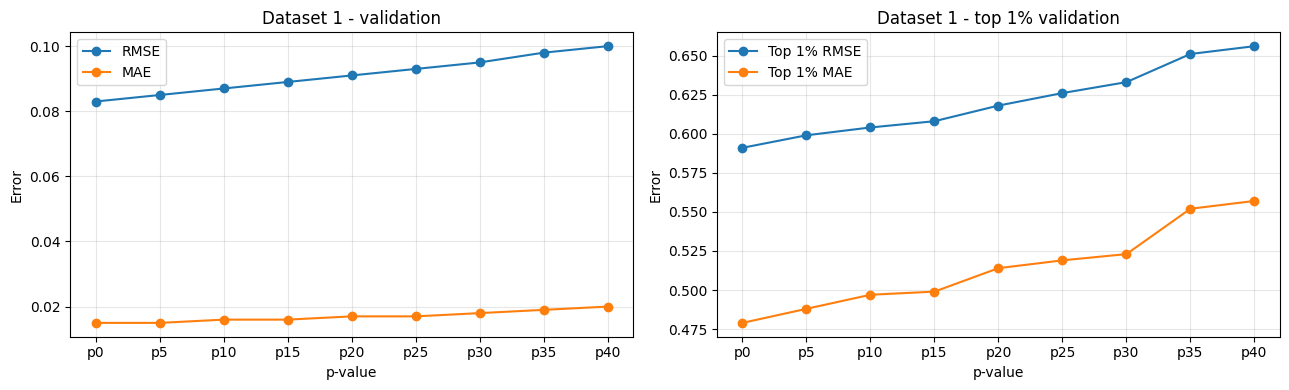

,p_value,experiment,model,validation_rmse,validation_mae,validation_top1_rmse,validation_top1_mae
0,p0,dataset1_temporal_retrain_loaded_04a_centrality,Gradient Boosting (tuned),0.083,0.015,0.591,0.479
8,p5,dataset1_temporal_retrain_loaded_04a_centrality,Gradient Boosting (tuned),0.085,0.015,0.599,0.488
1,p10,dataset1_temporal_retrain_loaded_04a_centrality,Gradient Boosting (tuned),0.087,0.016,0.604,0.497
2,p15,dataset1_temporal_retrain_loaded_04a_centrality,Gradient Boosting (tuned),0.089,0.016,0.608,0.499
3,p20,dataset1_temporal_retrain_loaded_04a_centrality,Gradient Boosting (tuned),0.091,0.017,0.618,0.514
4,p25,dataset1_temporal_retrain_loaded_04a_centrality,Gradient Boosting (tuned),0.093,0.017,0.626,0.519
5,p30,dataset1_temporal_retrain_loaded_04a_centrality,Gradient Boosting (tuned),0.095,0.018,0.633,0.523
6,p35,dataset1_temporal_retrain_loaded_04a_centrality,Gradient Boosting (tuned),0.098,0.019,0.651,0.552
7,p40,dataset1_temporal_retrain_loaded_04a_centrality,Gradient Boosting (tuned),0.100,0.020,0.656,0.557


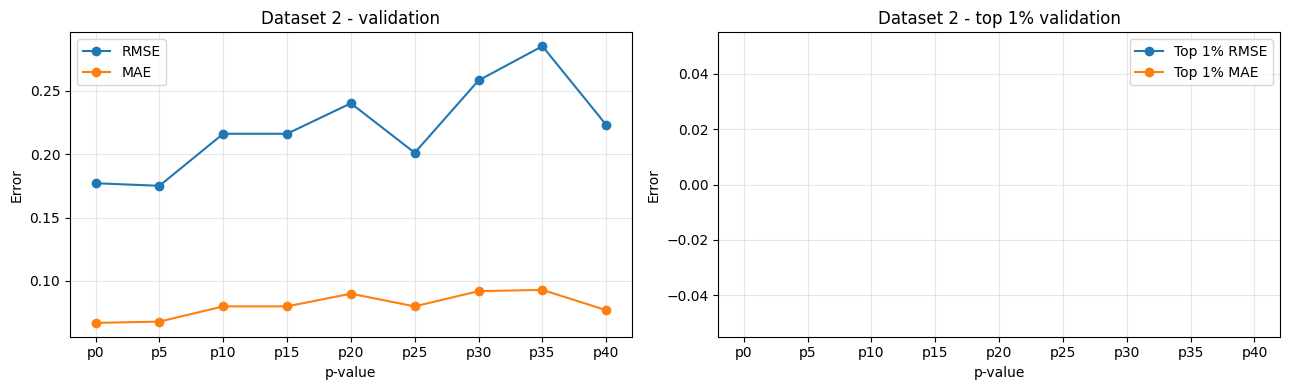

,p_value,experiment,model,validation_rmse,validation_mae,validation_top1_rmse,validation_top1_mae
0,p0,dataset2_random_train_04a_specs,Gradient Boosting (tuned),0.177,0.067,NaN,NaN
8,p5,dataset2_random_train_04a_specs,Gradient Boosting (tuned),0.175,0.068,NaN,NaN
1,p10,dataset2_random_train_04a_specs,Gradient Boosting (tuned),0.216,0.080,NaN,NaN
2,p15,dataset2_random_train_04a_specs,Gradient Boosting (tuned),0.216,0.080,NaN,NaN
3,p20,dataset2_random_train_04a_specs,Gradient Boosting (tuned),0.240,0.090,NaN,NaN
4,p25,dataset2_random_train_04a_specs,Gradient Boosting (tuned),0.201,0.080,NaN,NaN
5,p30,dataset2_random_train_04a_specs,Gradient Boosting (tuned),0.258,0.092,NaN,NaN
6,p35,dataset2_random_train_04a_specs,Gradient Boosting (tuned),0.285,0.093,NaN,NaN
7,p40,dataset2_random_train_04a_specs,Gradient Boosting (tuned),0.223,0.077,NaN,NaN


: 

In [ ]:
def prepare_p_plot_data(results_df, dataset_prefix):
    baseline_name = f'{dataset_prefix}_baseline'
    is_baseline = results_df['dataset'].eq(baseline_name)
    is_p_value = results_df['dataset'].str.startswith(f'{dataset_prefix}_p')
    plot_df = results_df[is_baseline | is_p_value].copy()

    plot_df['p_value'] = plot_df['dataset'].str.extract(r'_(p\d+)$')[0]
    plot_df.loc[plot_df['dataset'].eq(baseline_name), 'p_value'] = 'p0'
    plot_df['p_num'] = plot_df['p_value'].str.extract(r'p(\d+)').astype(int)

    best = (
        plot_df.sort_values(['dataset', 'validation_rmse', 'validation_mae'])
        .groupby('dataset', as_index=False)
        .first()
        .sort_values('p_num')
    )
    return best


def plot_p_value_comparison(results_df, dataset_prefix, title):
    best = prepare_p_plot_data(results_df, dataset_prefix)

    fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharex=True)

    axes[0].plot(best['p_value'], best['validation_rmse'], marker='o', label='RMSE')
    axes[0].plot(best['p_value'], best['validation_mae'], marker='o', label='MAE')
    axes[0].set_title(f'{title} - validation')
    axes[0].set_xlabel('p-value')
    axes[0].set_ylabel('Error')
    axes[0].grid(True, alpha=0.3)
    axes[0].legend()

    axes[1].plot(best['p_value'], best['validation_top1_rmse'], marker='o', label='Top 1% RMSE')
    axes[1].plot(best['p_value'], best['validation_top1_mae'], marker='o', label='Top 1% MAE')
    axes[1].set_title(f'{title} - top 1% validation')
    axes[1].set_xlabel('p-value')
    axes[1].set_ylabel('Error')
    axes[1].grid(True, alpha=0.3)
    axes[1].legend()

    fig.tight_layout()
    plt.show()

    display_cols = [
        'p_value', 'experiment', 'model',
        'validation_rmse', 'validation_mae', 'validation_top1_rmse', 'validation_top1_mae',
    ]
    display(best[display_cols])


plot_p_value_comparison(results, 'dataset1', 'Dataset 1')
plot_p_value_comparison(results, 'dataset2', 'Dataset 2')